# Deep Learning Image Classification using ANN and CNN

This project demonstrates image classification using Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN).

The objective of this project is to compare the performance of ANN and CNN models for image-based classification tasks using Deep Learning techniques.

## Technologies Used
- Python
- TensorFlow
- Keras
- NumPy
- Matplotlib

## Concepts Covered
- Artificial Neural Networks
- Convolutional Neural Networks
- Deep Learning
- Image Classification
- Model Evaluation

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


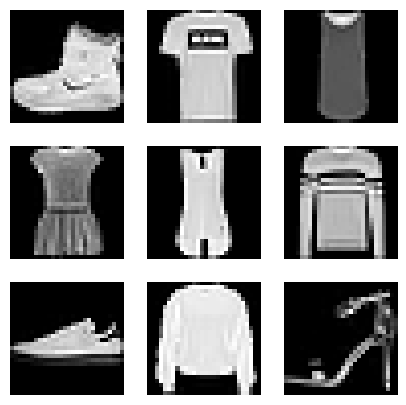

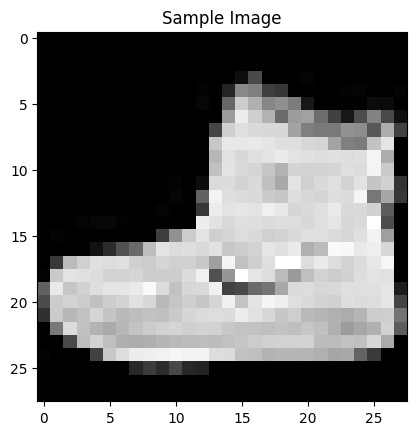

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8228 - loss: 0.4946
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8628 - loss: 0.3687
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8775 - loss: 0.3339
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8838 - loss: 0.3104
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8917 - loss: 0.2910
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8744 - loss: 0.3597

ANN Model Accuracy : 0.8744000196456909


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.8608 - loss: 0.3905
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9026 - loss: 0.2665
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9179 - loss: 0.2227
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9302 - loss: 0.1898
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9392 - loss: 0.1626
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9065 - loss: 0.2589

CNN Model Accuracy : 0.906499981880188

Final Comparison:

CNN model performed better than ANN model.


In [1]:
# importing required libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D


# loading fashion mnist dataset

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()


# displaying sample dataset images

plt.figure(figsize=(5,5))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(x_train[i], cmap="gray")

    plt.axis("off")

plt.show()


# normalizing dataset

x_train = x_train / 255.0

x_test = x_test / 255.0


# displaying sample image

plt.imshow(x_train[0], cmap="gray")

plt.title("Sample Image")

plt.show()


# ANN MODEL

ann_model = Sequential()

ann_model.add(Flatten(input_shape=(28, 28)))

ann_model.add(Dense(128, activation="relu"))

ann_model.add(Dense(64, activation="relu"))

ann_model.add(Dense(10, activation="softmax"))


# compiling ANN model

ann_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# training ANN model

ann_model.fit(
    x_train,
    y_train,
    epochs=5
)


# evaluating ANN model

ann_loss, ann_accuracy = ann_model.evaluate(
    x_test,
    y_test
)

print("\nANN Model Accuracy :", ann_accuracy)


# CNN MODEL

# reshaping dataset for CNN

x_train_cnn = x_train.reshape(-1, 28, 28, 1)

x_test_cnn = x_test.reshape(-1, 28, 28, 1)


cnn_model = Sequential()

cnn_model.add(
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    )
)

cnn_model.add(MaxPooling2D((2, 2)))

cnn_model.add(Flatten())

cnn_model.add(Dense(128, activation="relu"))

cnn_model.add(Dense(10, activation="softmax"))


# compiling CNN model

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# training CNN model

cnn_model.fit(
    x_train_cnn,
    y_train,
    epochs=5
)


# evaluating CNN model

cnn_loss, cnn_accuracy = cnn_model.evaluate(
    x_test_cnn,
    y_test
)

print("\nCNN Model Accuracy :", cnn_accuracy)


# final comparison

print("\nFinal Comparison:\n")

if cnn_accuracy > ann_accuracy:

    print("CNN model performed better than ANN model.")

else:

    print("ANN model performed better than CNN model.")